<a href="https://colab.research.google.com/github/m-aryan/Social_Media_Sentiment_Polarity_on_Consumer_Purchase_Intention/blob/main/Social_Media_Sentiment_Polarity_on_Consumer_Purchase_Intention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Setup**

### **Mount Drive**

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


### **Load Dataset + Get Dataset Metadata**

In [4]:
import pandas as pd

filePath = '/content/gdrive/MyDrive/MBA PROJECT/dataset_1.csv'
dataSet = pd.read_csv(filePath)

In [5]:
print(f"Dataframe's Shape : {dataSet.shape}")
print(f"\nNumber of Columns : {dataSet.columns.tolist()}")


Dataframe's Shape : (28332, 24)

Number of Columns : ['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand', 'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer', 'manufacturerNumber', 'reviews.date', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs']


#

---

# **Project Runtime Setup**

### **Install dependencies which are not already installed**

In [6]:
!pip install vaderSentiment
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.9 MB/s eta 0:00:00


### **Load Dependencies (Import Statements)**

In [7]:
# Import Statements
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from tqdm import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.stats import pearsonr, f_oneway, pointbiserialr
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [8]:
# Configuring Dependencies
warnings.filterwarnings('ignore')
tqdm.pandas()
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (10, 5)

### **Previewing Dataset**

In [9]:
# Creating dataset's working copy to maintain original copy of dataSet imported.

df = dataSet.copy()
df.head(2)

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."


In [10]:
# Finding Missing Values in working copy of Dataset

key_cols = ['reviews.text', 'reviews.rating',
            'reviews.doRecommend', 'primaryCategories',
            'reviews.numHelpful', 'reviews.title']

print("\n---------------------------- Missing Values ----------------------------\n")
print(df[key_cols].isnull().sum())

# Rating Distribution
print("\n------------------------- Ratings Distribution -------------------------\n")
print(df['reviews.rating'].value_counts().sort_index())

# Primary Categories
print("\n-------------------------- Primary Categories --------------------------\n")
print(df['primaryCategories'].value_counts())


---------------------------- Missing Values ----------------------------

reviews.text               0
reviews.rating             0
reviews.doRecommend    12246
primaryCategories          0
reviews.numHelpful     12217
reviews.title              0
dtype: int64

------------------------- Ratings Distribution -------------------------

reviews.rating
1      965
2      616
3     1206
4     5648
5    19897
Name: count, dtype: int64

-------------------------- Primary Categories --------------------------

primaryCategories
Electronics                    13995
Health & Beauty                12071
Toys & Games,Electronics        1676
Office Supplies,Electronics      386
Electronics,Media                185
Office Supplies                    9
Animals & Pet Supplies             6
Home & Garden                      2
Electronics,Furniture              2
Name: count, dtype: int64


#

---

# **Data Cleaning**

### **Removing unwanted columsn from working copy of dataset**

In [11]:
# Keeping Relevant cols and removing unwanted columns
df = df[['reviews.text', 'reviews.rating', 'reviews.doRecommend',
         'primaryCategories', 'reviews.numHelpful',
         'reviews.title', 'brand', 'name']].copy()
df.head(2)

,reviews.text,reviews.rating,reviews.doRecommend,primaryCategories,reviews.numHelpful,reviews.title,brand,name
0,I order 3 of them and one of the item is bad q...,3,NaN,Health & Beauty,NaN,... 3 of them and one of the item is bad quali...,Amazonbasics,AmazonBasics AAA Performance Alkaline Batterie...
1,Bulk is always the less expensive way to go fo...,4,NaN,Health & Beauty,NaN,... always the less expensive way to go for pr...,Amazonbasics,AmazonBasics AAA Performance Alkaline Batterie...


### **Renaming columns for easy reference**

In [12]:
# renaming cols for easy usage
print(f"Col. Names before renaming : \n{df.columns.tolist()}")
df.columns = ['review_text', 'rating', 'do_recommend',
              'category', 'num_helpful',
              'review_title', 'brand', 'product_name']

print(f"\n\nCol. Names after renaming : \n{df.columns.tolist()}")

Col. Names before renaming : 
['reviews.text', 'reviews.rating', 'reviews.doRecommend', 'primaryCategories', 'reviews.numHelpful', 'reviews.title', 'brand', 'name']


Col. Names after renaming : 
['review_text', 'rating', 'do_recommend', 'category', 'num_helpful', 'review_title', 'brand', 'product_name']


### **Drop irrelevant rows and clean important columns**

In [13]:
# Dropping rows missing critical columns
df.dropna(subset = ['review_text', 'rating'], inplace=True)

In [14]:
# Clean Ratings

df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df = df[df['rating'].between(1, 5)]
df['rating'] = df['rating'].astype(int)

In [15]:
# Clean do_recommend

df['do_recommend'] = df['do_recommend'].map(
    {True: 1, False: 0, 'TRUE': 1, 'FALSE': 0}
)

### **Fill missing `num_helpful` count with `0` + remove noise**

In [16]:
df['num_helpful'] = df['num_helpful'].fillna(0)

In [17]:
df = df[df['review_text'].str.len() >= 10]

### **Reset Index for further analysis**

In [18]:
df.reset_index(drop=True, inplace=True)

### **Updated metadata for dataset post cleaning**

In [19]:
# Rating Distribution
print("\n------------------------- Ratings Distribution -------------------------\n")
print(df['rating'].value_counts().sort_index())

# Do Recommend
print("\n----------------------------- Do Recommend -----------------------------\n")
print(df['do_recommend'].value_counts())


------------------------- Ratings Distribution -------------------------

rating
1      958
2      613
3     1179
4     5539
5    19213
Name: count, dtype: int64

----------------------------- Do Recommend -----------------------------

do_recommend
1.0    15353
0.0      733
Name: count, dtype: int64


#

---

# **VADER Sentiment Scoring**

### **Define : compound score & sentiment classification**

In [20]:
analyzer = SentimentIntensityAnalyzer()

In [21]:
# Compound Score
def get_compount_score(text):
  return analyzer.polarity_scores(str(text))['compound']


# Sentiment Classification
def classify_sentiment(score):
  if (score >= 0.05):
    return 'Positive'
  elif (score <= -0.05):
    return 'Negative'
  else:
    return 'Neutral'

### **Add Compound Score in Dataset w.r.t. `review_text`**



In [22]:
print("Running sentiment analysis...")
df['compound_score'] = df['review_text'].progress_apply(get_compount_score)
print("\nSentiment analysis completed")

Running sentiment analysis...


100%|██████████| 27502/27502 [00:08<00:00, 3112.16it/s]


Sentiment analysis completed


### **Add Sentiment in Dataset w.r.t. `compound_score`**

In [23]:
print("Classifying Sentiments...")
df['sentiment'] = df['compound_score'].progress_apply(classify_sentiment)
print("\nSentiments Added Successfully")

Classifying Sentiments...


100%|██████████| 27502/27502 [00:00<00:00, 290248.57it/s]


Sentiments Added Successfully


### **Sentiment Distribution & percent breakdown**

In [24]:
# Sentiment Distribution
print("\n------------------------ Sentiment Distribution ------------------------\n")
print(df['sentiment'].value_counts())

# Sentiment Percent Breakdown
print("\n--------------------- Sentiments Percent Breakdown ---------------------\n")
print((df['sentiment'].value_counts(normalize=True)*100).round(2))


------------------------ Sentiment Distribution ------------------------

sentiment
Positive    23242
Neutral      2337
Negative     1923
Name: count, dtype: int64

--------------------- Sentiments Percent Breakdown ---------------------

sentiment
Positive    84.51
Neutral      8.50
Negative     6.99
Name: proportion, dtype: float64


#

---

# **Descriptive Statistics Table**

### **Descriptive Statistics**

In [25]:
print("\n------------------------ DESCRIPTIVE STATISTICS ------------------------\n")

desc = df.groupby('sentiment').agg(
    Count=('rating', 'count'),
    Mean_Rating=('rating', 'mean'),
    Std_Rating=('rating', 'std'),
    Min_Rating=('rating', 'min'),
    Max_Rating=('rating', 'max'),
    Mean_Sentiment_Score=('compound_score', 'mean')
).round(3)

print(desc)

print("\n-------------------- OVERALL DESCRIPTIVE STATISTICS --------------------\n")
print(df[['compound_score', 'rating']].describe().round(3))


------------------------ DESCRIPTIVE STATISTICS ------------------------

           Count  Mean_Rating  Std_Rating  Min_Rating  Max_Rating  \
sentiment                                                           
Negative    1923        3.039       1.608           1           5   
Neutral     2337        4.194       1.225           1           5   
Positive   23242        4.659       0.688           1           5   

           Mean_Sentiment_Score  
sentiment                        
Negative                 -0.437  
Neutral                   0.000  
Positive                  0.696  

-------------------- OVERALL DESCRIPTIVE STATISTICS --------------------

       compound_score     rating
count       27502.000  27502.000
mean            0.558      4.507
std             0.391      0.942
min            -0.985      1.000
25%             0.422      4.000
50%             0.674      5.000
75%             0.848      5.000
max             0.999      5.000


#

---

# **EDA - Charts**

In [26]:
colors = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}
order = ['Positive', 'Neutral', 'Negative']

### **Chart: Sentiment Distribution**

In [27]:
def plot_sentiment_distribution(ax):
    sentiment_counts = df['sentiment'].value_counts().reindex(order)

    bars = ax.bar(
        order,
        sentiment_counts.values,
        color=[colors[s] for s in order],
        edgecolor='white',
        linewidth=0.8
    )

    ax.set_title('Fig 1.1: Distribution of Sentiment Polarity', fontweight='bold')
    ax.set_xlabel('Sentiment Category')
    ax.set_ylabel('Number of Reviews')

    for bar, val in zip(bars, sentiment_counts.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center',
            fontsize=9,
            fontweight='bold'
        )

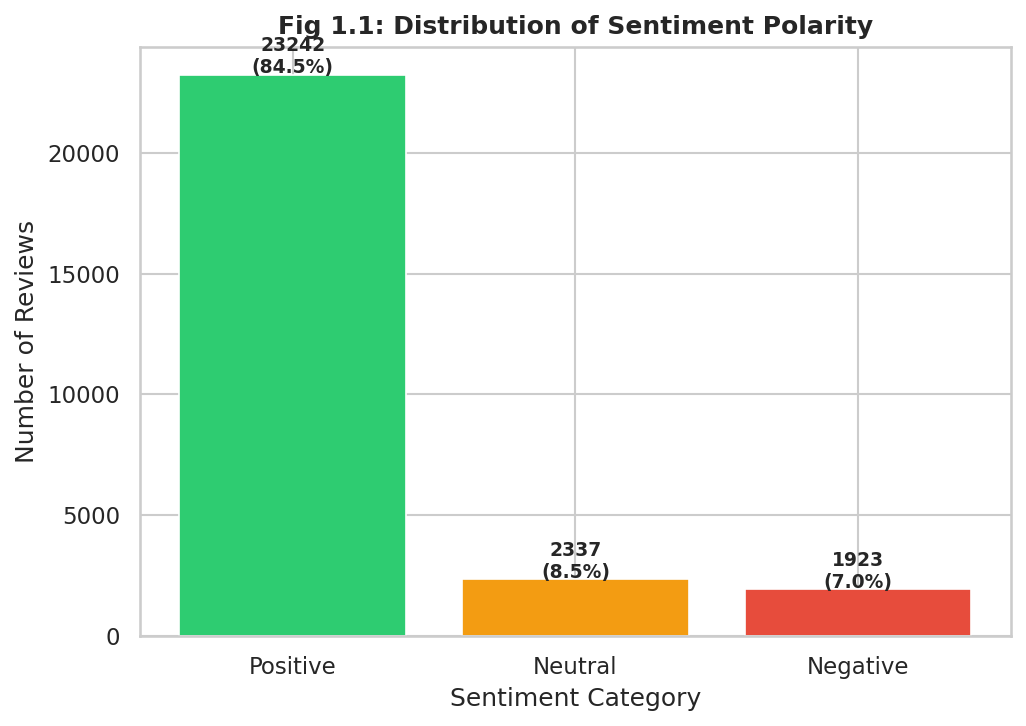

In [28]:
fig, ax = plt.subplots(figsize=(7,5))
plot_sentiment_distribution(ax)
plt.tight_layout()
plt.savefig("Fig1_1_Sentiment_Distribution.png", dpi=150)
plt.show()

### **Chart : Average Rating by Sentiment Class**

In [29]:
def plot_average_rating(ax):
    avg_rating = df.groupby('sentiment')['rating'].mean().reindex(order)

    bars = ax.bar(
        order,
        avg_rating.values,
        color=[colors[s] for s in order],
        edgecolor='white'
    )

    ax.set_title('Fig 1.2: Average Rating by Sentiment Class', fontweight='bold')
    ax.set_xlabel('Sentiment Category')
    ax.set_ylabel('Average Rating (1–5)')
    ax.set_ylim(0, 6)

    for bar, val in zip(bars, avg_rating.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{val:.2f}',
            ha='center',
            fontweight='bold'
        )

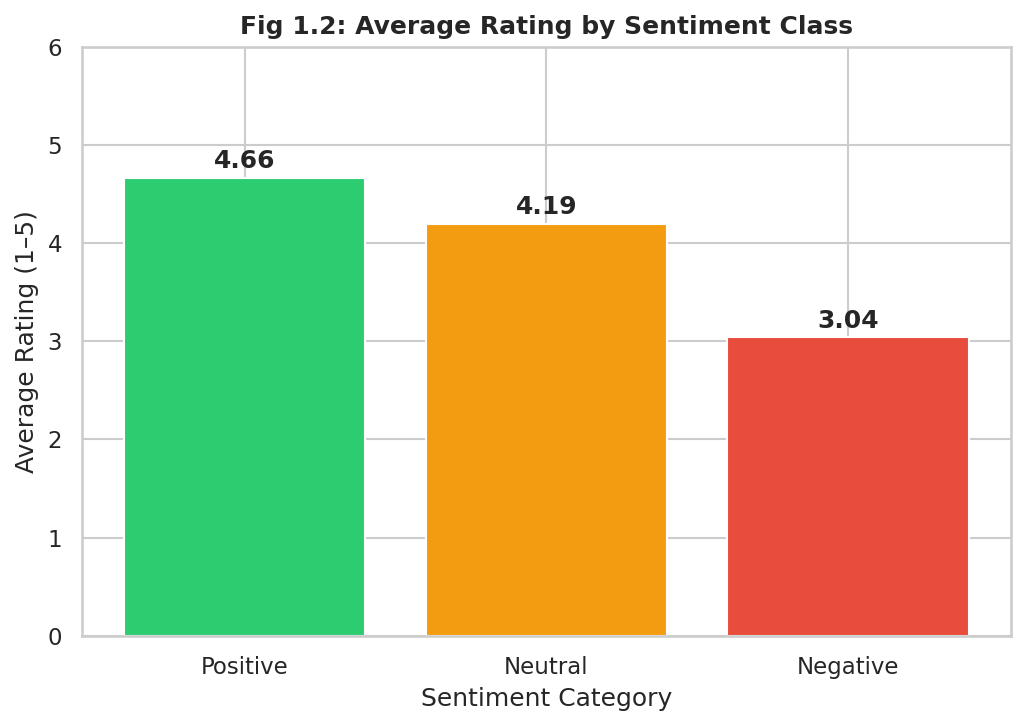

In [30]:
fig, ax = plt.subplots(figsize=(7,5))
plot_average_rating(ax)
plt.tight_layout()
plt.savefig("Fig1_2_Average_Rating.png", dpi=150)
plt.show()

### **Chart: Rating Distribution**

In [31]:
def plot_boxplot(ax):
    bp = ax.boxplot(
        [df[df['sentiment'] == s]['rating'].values for s in order],
        labels=order,
        patch_artist=True,
        boxprops=dict(linewidth=1.5),
        medianprops=dict(color='black', linewidth=2)
    )

    for patch, s in zip(bp['boxes'], order):
        patch.set_facecolor(colors[s])
        patch.set_alpha(0.7)

    ax.set_title('Fig 1.3: Rating Distribution by Sentiment Class', fontweight='bold')
    ax.set_xlabel('Sentiment Category')
    ax.set_ylabel('Rating (1–5)')

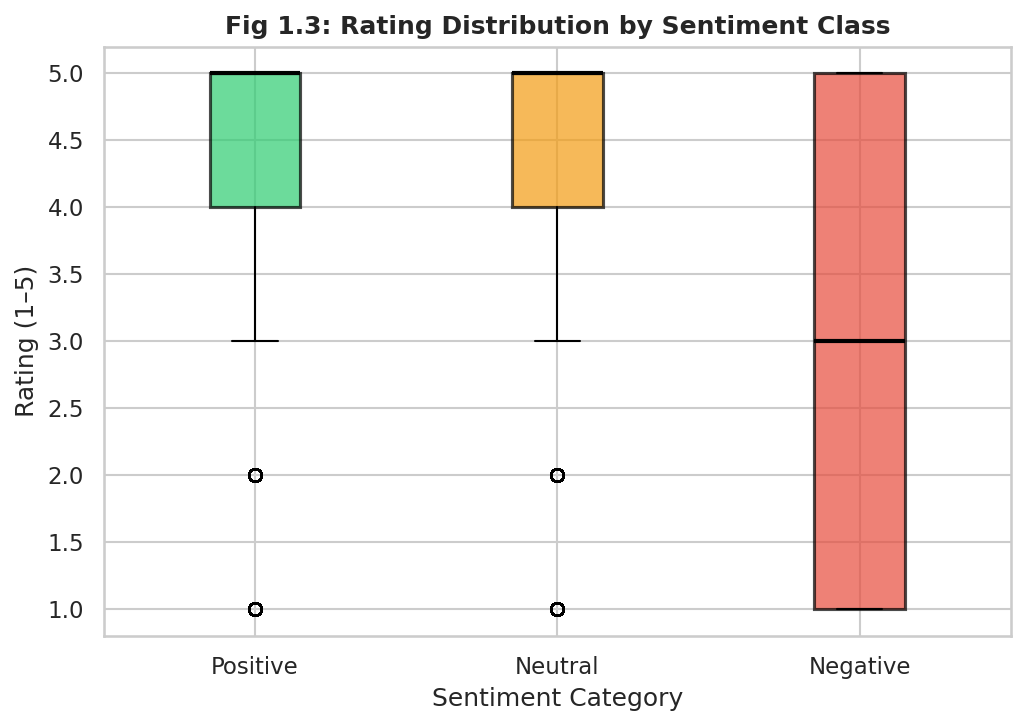

In [32]:
fig, ax = plt.subplots(figsize=(7,5))
plot_boxplot(ax)
plt.tight_layout()
plt.savefig("Fig1_3_Boxplot.png", dpi=150)
plt.show()

### **Chart : Scatter Plot**

In [33]:
def plot_scatter(ax):
    sample = df.sample(n=2000, random_state=42)

    for s in order:
        subset = sample[sample['sentiment'] == s]
        ax.scatter(
            subset['compound_score'],
            subset['rating'],
            alpha=0.3,
            color=colors[s],
            s=15,
            label=s
        )

    m, b = np.polyfit(sample['compound_score'], sample['rating'], 1)

    x_line = np.linspace(-1, 1, 100)

    ax.plot(
        x_line,
        m * x_line + b,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Trend line'
    )

    ax.set_title('Fig 1.4: Sentiment Score vs. Consumer Rating', fontweight='bold')
    ax.set_xlabel('VADER Compound Score')
    ax.set_ylabel('Product Rating')
    ax.legend(fontsize=8)

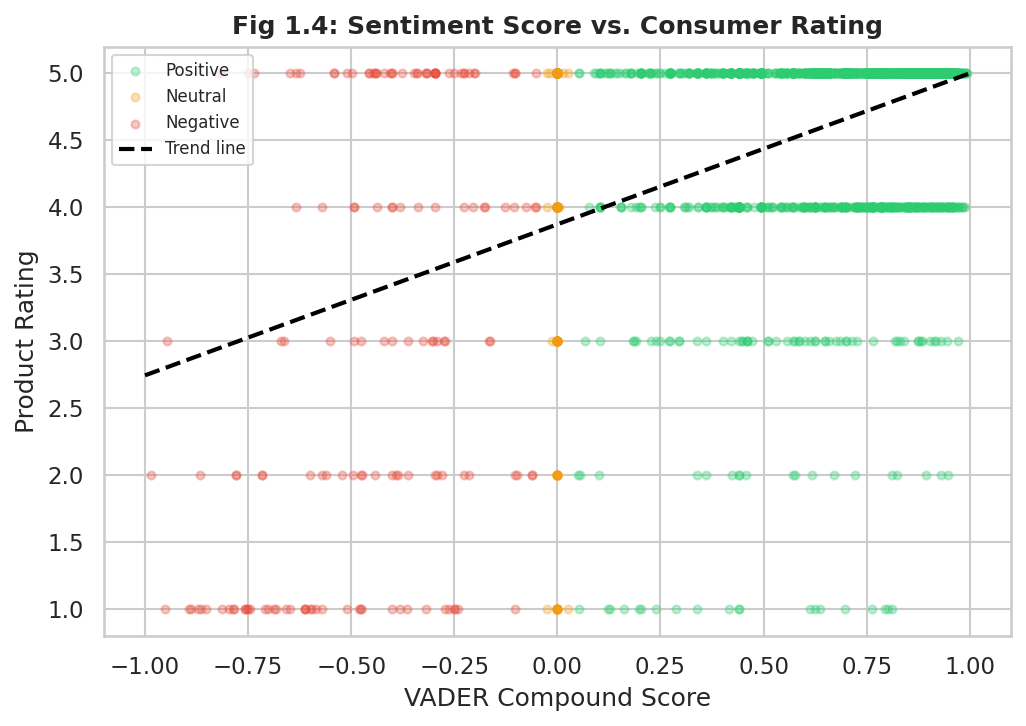

In [34]:
fig, ax = plt.subplots(figsize=(7,5))
plot_scatter(ax)
plt.tight_layout()
plt.savefig("Fig1_4_Scatter.png", dpi=150)
plt.show()

### **Consolidated Chart of above 4 charts**

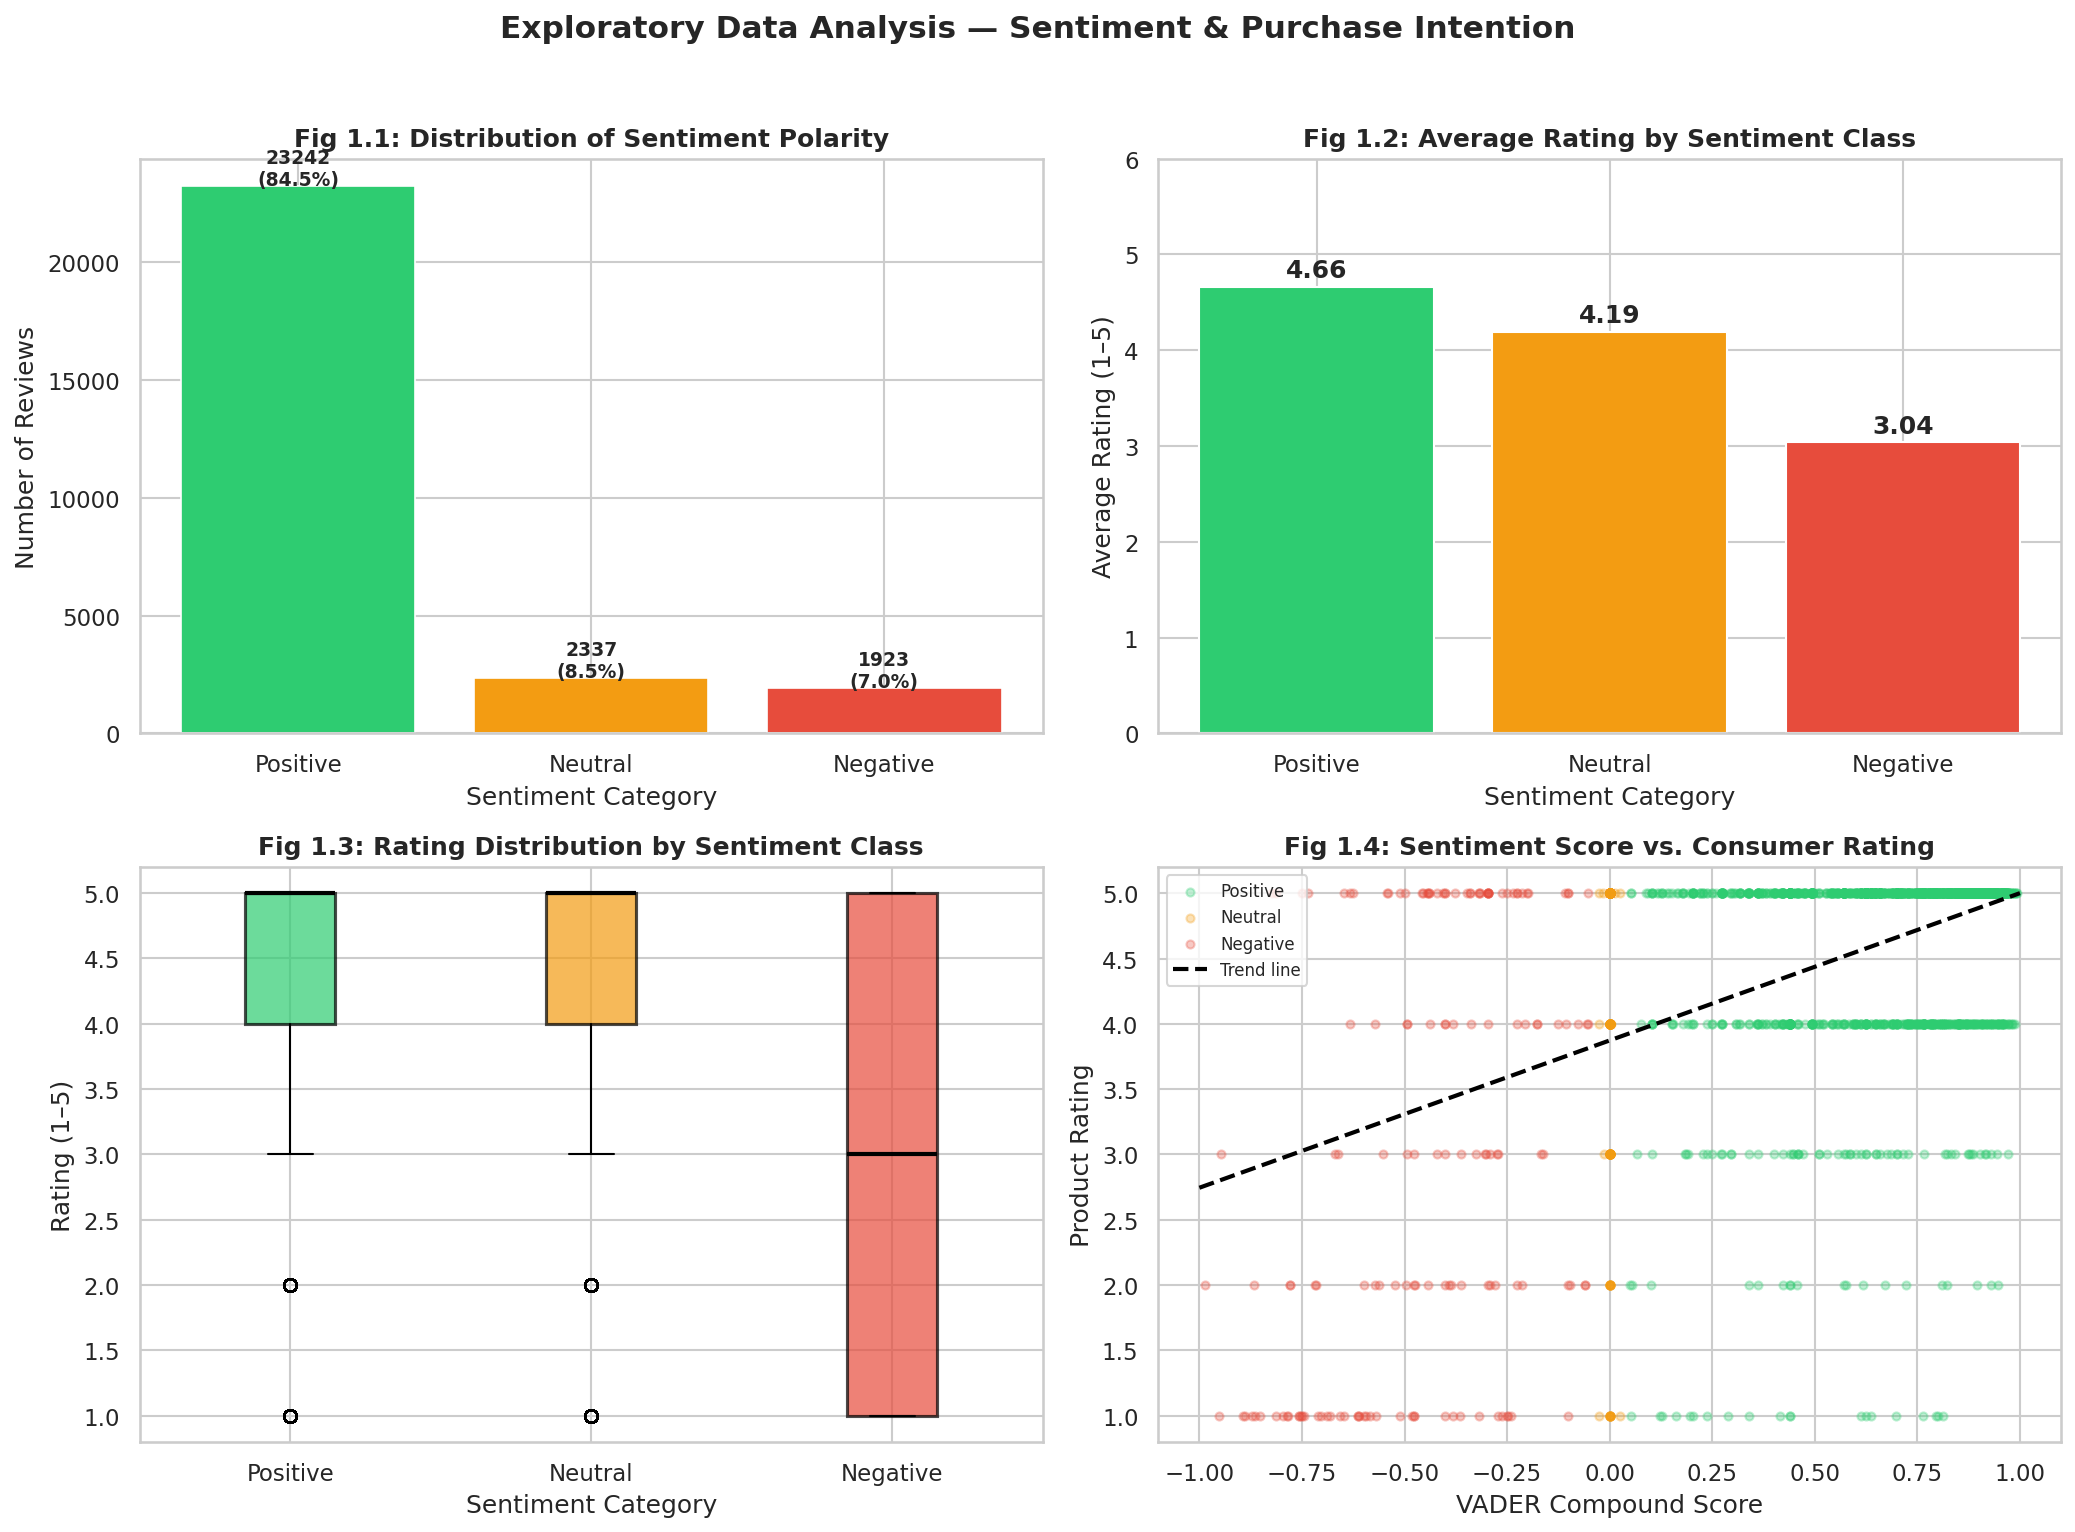

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(
    'Exploratory Data Analysis — Sentiment & Purchase Intention',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plot_sentiment_distribution(axes[0, 0])
plot_average_rating(axes[0, 1])
plot_boxplot(axes[1, 0])
plot_scatter(axes[1, 1])

plt.tight_layout()
plt.savefig("Fig1_EDA_Charts.png", dpi=150, bbox_inches='tight')
plt.show()


#

---

# **Hypothesis Testing**

### **H1 : Pearson Correlation >>> Sentiment Score vs Rating**

In [36]:
print("\nH1 : Sentiment Polarity --> Consumer Rating (Purchase Intention)")
print("-"*64)
corr, p_val = pearsonr(df['compound_score'], df['rating'])
print(f"Pearson r    =  {corr:.4f}")
print(f"P-value      =  {p_val:.6f}")
print(f"R-squared    =  {corr**2:.4f} ({corr**2*100:.2f}% variance explained)")
print(f"Significance =  {'Significant (p < 0.05)' if p_val < 0.05 else 'Not Significant'}")
print(f"H1 Result    =  {'ACCEPTED' if p_val < 0.05 and corr > 0 else 'REJECTED'}")


H1 : Sentiment Polarity --> Consumer Rating (Purchase Intention)
----------------------------------------------------------------
Pearson r    =  0.4554
P-value      =  0.000000
R-squared    =  0.2074 (20.74% variance explained)
Significance =  Significant (p < 0.05)
H1 Result    =  ACCEPTED


### **H2 : Point Biserial >>> Sentiment Score vs do_Recommend**

In [37]:
print("\nH2 : Sentiment Polarity --> Purchase Recommendation Intention")
print("-"*61)
df_rec = df.dropna(subset=['do_recommend'])
if len(df_rec) > 0:
    corr2, p_val2 = pointbiserialr(df_rec['do_recommend'], df_rec['compound_score'])
    print(f"Point-Biserial r =  {corr2:.4f}")
    print(f"P-value          =  {p_val2:.6f}")
    print(f"Significance     =  {'Significant (p < 0.05)' if p_val2 < 0.05 else 'Not Significant'}")
    print(f"H2 Result        =  {'ACCEPTED' if p_val2 < 0.05 and corr2 > 0 else 'REJECTED'}")
else:
    print("Insufficient doRecommend data — skipping H2")


H2 : Sentiment Polarity --> Purchase Recommendation Intention
-------------------------------------------------------------
Point-Biserial r =  0.3506
P-value          =  0.000000
Significance     =  Significant (p < 0.05)
H2 Result        =  ACCEPTED


### **H3 : One-way ANOVA >>> Rating across sentiment groups**

In [38]:
print("\nH3 : Mean Rating differs significantly across Sentiment Groups")
print("-"*62)
pos_ratings = df[df['sentiment']=='Positive']['rating']
neu_ratings = df[df['sentiment']=='Neutral']['rating']
neg_ratings = df[df['sentiment']=='Negative']['rating']

f_stat, anova_p = f_oneway(pos_ratings, neu_ratings, neg_ratings)
print(f"F-statistic  =  {f_stat:.4f}")
print(f"P-value      =  {anova_p:.6f}")
print(f"Significance =  {'Significant (p < 0.05)' if anova_p < 0.05 else 'Not Significant'}")
print(f"H3 Result    =  {'ACCEPTED' if anova_p < 0.05 else 'REJECTED'}")

print("\nGroup Means:")
print(df.groupby('sentiment')['rating'].mean().reindex(order).round(3))


H3 : Mean Rating differs significantly across Sentiment Groups
--------------------------------------------------------------
F-statistic  =  3465.4996
P-value      =  0.000000
Significance =  Significant (p < 0.05)
H3 Result    =  ACCEPTED

Group Means:
sentiment
Positive    4.659
Neutral     4.194
Negative    3.039
Name: rating, dtype: float64


#

---

# **POST-HOC Tukey + OLS Regression**

### **POST-Hoc Tukey**

In [41]:
print("\n------------------------ POST-HOC TUKEY HSD TEST ------------------------\n")
tukey = pairwise_tukeyhsd(endog=df['rating'], groups=df['sentiment'], alpha=0.05)
print(tukey)


------------------------ POST-HOC TUKEY HSD TEST ------------------------

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1   group2  meandiff p-adj lower  upper  reject
-----------------------------------------------------
Negative  Neutral   1.1553   0.0 1.0945  1.216   True
Negative Positive   1.6205   0.0 1.5737 1.6673   True
 Neutral Positive   0.4652   0.0 0.4224 0.5081   True
-----------------------------------------------------


### **OLS Regression**

In [45]:
print("\n------------------------- OLS LINEAR REGRESSION -------------------------")
print("---------- DV : Consumer Rating | IV: Sentiment Compound Score ----------\n")

x = sm.add_constant(df['compound_score'])
y = df['rating']

model = sm.OLS(y, x).fit()
print(model.summary())


------------------------- OLS LINEAR REGRESSION -------------------------
---------- DV : Consumer Rating | IV: Sentiment Compound Score ----------

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                     7195.
Date:                Sun, 05 Jul 2026   Prob (F-statistic):               0.00
Time:                        07:34:58   Log-Likelihood:                -34186.
No. Observations:               27502   AIC:                         6.838e+04
Df Residuals:                   27500   BIC:                         6.839e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|  

#

---

#

---

#

---

#

---

#

---